<a href="https://www.kaggle.com/code/udayrajkarki/mall-customers-pattern-analysis?scriptVersionId=305581341" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os

# See what files are available
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# Load your CSV (replace the path with your actual file)
df = pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
df.head()

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


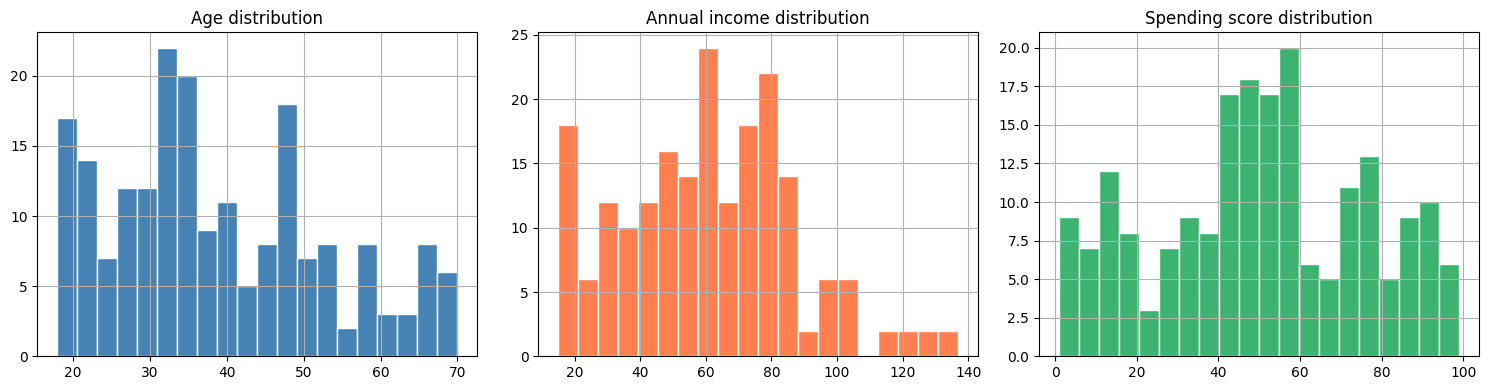

Gender
Female    112
Male       88
Name: count, dtype: int64


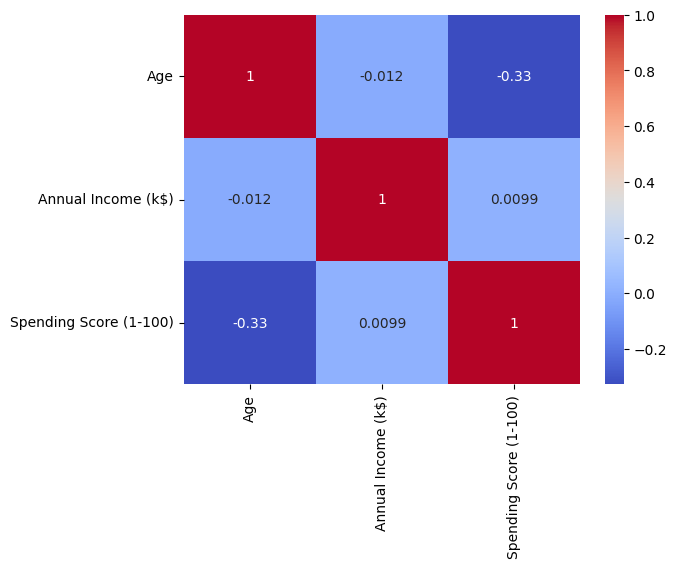

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Age'].hist(ax=axes[0], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Age distribution')

df['Annual Income (k$)'].hist(ax=axes[1], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Annual income distribution')

df['Spending Score (1-100)'].hist(ax=axes[2], bins=20, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Spending score distribution')

plt.tight_layout()
plt.show()

# Gender split
print(df['Gender'].value_counts())

# Correlation
sns.heatmap(df.drop('CustomerID', axis=1).select_dtypes(include='number').corr(),
            annot=True, cmap='coolwarm')
plt.show()

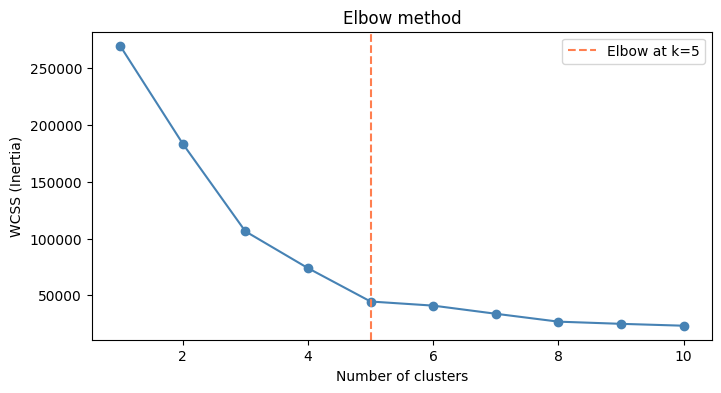

In [5]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    km.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue')
plt.axvline(x=5, color='coral', linestyle='--', label='Elbow at k=5')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow method')
plt.legend()
plt.show()

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

km = KMeans(n_clusters=5, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = km.fit_predict(X)

print(df['Cluster'].value_counts().sort_index())

Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


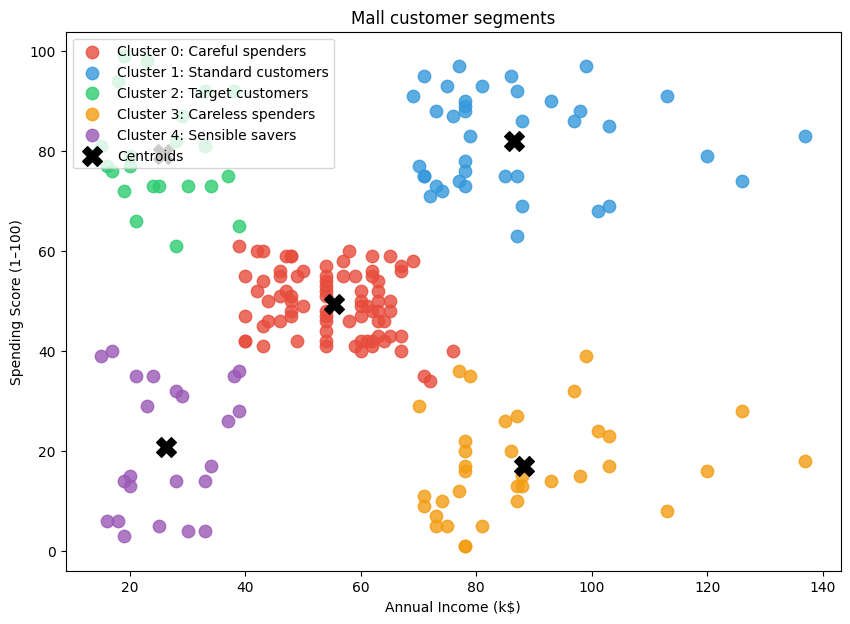

In [7]:
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
labels = ['Careful spenders', 'Standard customers', 'Target customers',
          'Careless spenders', 'Sensible savers']

plt.figure(figsize=(10, 7))
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                s=80, color=colors[i], label=f'Cluster {i}: {labels[i]}', alpha=0.8)

# Plot centroids
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            s=200, c='black', marker='X', zorder=5, label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.title('Mall customer segments')
plt.legend(loc='upper left')
plt.show()

In [8]:
cluster_profile = df.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Score=('Spending Score (1-100)', 'mean')
).round(1)

print(cluster_profile)

         Count  Avg_Age  Avg_Income  Avg_Score
Cluster                                       
0           81     42.7        55.3       49.5
1           39     32.7        86.5       82.1
2           22     25.3        25.7       79.4
3           35     41.1        88.2       17.1
4           23     45.2        26.3       20.9


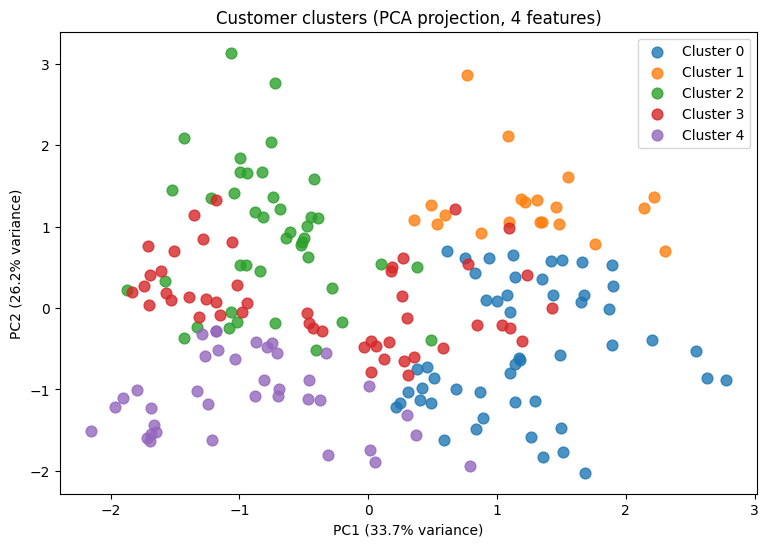

In [9]:
from sklearn.preprocessing import LabelEncoder

df2 = df.copy()
df2['Gender_enc'] = LabelEncoder().fit_transform(df2['Gender'])

features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_enc']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df2[features])

km3 = KMeans(n_clusters=5, random_state=42)
df2['Cluster3D'] = km3.fit_predict(X_scaled)

# Use PCA to visualize 4 dimensions in 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6))
for i in range(5):
    mask = df2['Cluster3D'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {i}', alpha=0.8, s=60)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Customer clusters (PCA projection, 4 features)')
plt.legend()
plt.show()

In [10]:
df.to_csv('customers_segmented.csv', index=False)
print("Saved! Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())

Saved! Cluster distribution:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
